# Import Statements

In [2]:
## Import statements
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
from geopy.distance import geodesic
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.image as mpimg

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Helper Functions

In [4]:
#Utility functions
def covertinit(row):
    return datetime.strptime(str(row['init']),'%Y%m%d%H')
    
def calcftime(row):
    return row['initdatetime']+timedelta(hours=row['fhour'])

def convertlat(row):
    latNS = row['lat'][-1]
    if (latNS=='N'):
        return float(row['lat'][:-1])/10.
    elif (latNS=='S'):
        return -float(row['lat'][:-1])/10.

def convertlon(row):
    lonEW = row['lon'][-1]
    if (lonEW=='E'):
        return float(row['lon'][:-1])/10.
    elif (lonEW=='W'):
        if (storm[1]=='p'):
            return 360.-float(row['lon'][:-1])/10.
        else:
            return -float(row['lon'][:-1])/10.

In [5]:
#Read in working best-track files
def readbdeck(storm):
    besttrack = pd.read_csv('/tanglab_rit/ATM527/googleDeepMind/publication_analysis/DATA/besttrack/b'+storm+'.dat',header=None, names=['stormnum','init','model','fhour','lat','lon','vmax','pmin','class'], \
                          usecols=[1,2,4,5,6,7,8,9,10], skipinitialspace=True, engine='python')
    
    besttrack['initdatetime'] = besttrack.apply(covertinit, axis=1)
    besttrack['flat'] = besttrack.apply(convertlat, axis=1)
    besttrack['flon'] = besttrack.apply(convertlon, axis=1)
    
    besttrack.drop(['init','lat','lon'],axis=1,inplace=True)
    
    #replace invalid entries (=0) with NaN
    besttrack.replace({'flat':0}, np.nan, inplace=True)
    besttrack.replace({'flon':0}, np.nan, inplace=True)
    besttrack.replace({'vmax':0}, np.nan, inplace=True)
    besttrack.replace({'pmin':0}, np.nan, inplace=True)
    
    #only keep rows where classification is TD, TS, SS, or HU (filter times where a disturbance or extratropical system)
    besttrack = besttrack[besttrack['class'].isin({'TD','TS','HU','SS'})]

    return besttrack

In [7]:
## Let's create the best track 24-hr intensity change for 2025.
storm_num = 13
bestrack_intensity_change = np.empty(0)
for i in range(storm_num):
    storm = 'al' + f"{i+1:02d}" + '2025'
    bestrack = readbdeck(storm)
    dates = np.unique(bestrack['initdatetime'].values)
    for j in range(len(dates) - 4):
        initial_intensity = bestrack[bestrack['initdatetime'] == dates[j]]['vmax'].values[0]
        final_intensity = bestrack[bestrack['initdatetime'] == dates[j] + np.timedelta64(24, 'h')]['vmax']
        if (len(final_intensity) == 0):
            continue
        final_intensity = final_intensity.values[0]
        bestrack_intensity_change = np.append(bestrack_intensity_change, final_intensity-initial_intensity) 

# Create array for storms that underwent RI in 2025

In [23]:
## Create array holding storm names for 2025
storm_names = np.array(['Andrea', 'Barry', 'Chantal', 'Dexter', 'Erin', 'Fernand', 'Gabrielle', 'Humberto', 'Imelda', 'Jerry', 'Karen', 'Lorenzo', 'Melissa'])

In [24]:
## Create array holding the times and storms that underwent RI
storms_that_underwent_RI = np.empty(0)
storm_code = np.empty(0)
RI_time = np.empty(0)
total_times = 0

## Open the list
for j in range(len(storm_names)):
    name = storm_names[j]
    original_list = pd.read_csv('/tanglab_rit/ATM527/googleDeepMind/cyclogenesis_reliability_diagram_season/data/data_CSU/' + name + '.csv')
    in_question = original_list.dropna()
    valid_times = np.empty(0)
    total_times += len(in_question)
    for i in range(len(in_question['Synoptic Time'])):
        valid_times = np.append(valid_times, datetime.strptime(in_question['Synoptic Time'][i], '%d/%m/%Y %H:%M'))
    
    in_question['Valid Time'] = valid_times
    last_time = in_question['Valid Time'][0]
    for i in range(len(in_question['Valid Time'])-1, -1, -1):
        time_in_question = in_question['Valid Time'][i]
        time_24_later = time_in_question + timedelta(hours=24)
        initial_intensity = in_question['Intensity'][i]
        if (time_24_later > last_time):
            break
        else:
            in_question_24_later = in_question[in_question['Valid Time'] == time_24_later]
            if (in_question_24_later['Intensity'].values[0] - initial_intensity >= 30):
                storms_that_underwent_RI = np.append(storms_that_underwent_RI, name)
                storm_code = np.append(storm_code, 'AL' + f"{j+1:02d}" + "2025")
                RI_time = np.append(RI_time, in_question['Valid Time'][i])

/tmp/ipykernel_3672132/1341796132.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  in_question['Valid Time'] = valid_times
/tmp/ipykernel_3672132/1341796132.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  in_question['Valid Time'] = valid_times
/tmp/ipykernel_3672132/1341796132.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [25]:
## Create a dataframe holding storms that underwent RI and when. 
RI = pd.DataFrame({'Time' : RI_time, 'Storm_Name' : storms_that_underwent_RI, 'Code' : storm_code})

In [26]:
RI

,Time,Storm_Name,Code
0,2025-08-15 06:00:00,Erin,AL052025
1,2025-08-15 12:00:00,Erin,AL052025
2,2025-08-15 18:00:00,Erin,AL052025
3,2025-08-16 00:00:00,Erin,AL052025
4,2025-09-21 12:00:00,Gabrielle,AL072025
5,2025-09-21 18:00:00,Gabrielle,AL072025
6,2025-09-22 00:00:00,Gabrielle,AL072025
7,2025-09-22 06:00:00,Gabrielle,AL072025
8,2025-09-25 12:00:00,Humberto,AL082025
9,2025-09-25 18:00:00,Humberto,AL082025


# Creating a CDF of Intensity Change over a Fixed Time Period

In [199]:
intensity_change = np.empty(0)

In [204]:
## Let's look at intensity changes over a 24 hour period.

## This will be the new and improved loop looping through all storms in the 2025 season! 

storm_num = 13 
hours = 0
records = []
## Loop through all 13 storms from the 2025 season!
for i in range(storm_num):
    storm = 'al' + f"{i+1:02d}" + '2025'
    bestrack = readbdeck(storm)
    ## Let's go through each time associated with the storm and pick out the associated track id.
    for j in range(len(np.unique(bestrack['initdatetime'].values))):
        ## Pick out the time in question
        date_in_question = np.unique(bestrack['initdatetime'].values)[j]
        ## Now let's open the file
        month = pd.to_datetime(date_in_question).month
        day = pd.to_datetime(date_in_question).day
        hour = pd.to_datetime(date_in_question).hour
        ## If it's a special hour/report, be sure to skip it! 
        if (hour % 6 != 0):
            continue
        if (month < 11):
            model_data = pd.read_csv('/tanglab_rit/ATM527/googleDeepMind/cyclogenesis_reliability_diagram_season/data/cyclogenesis/FNV3_' + str('2025') + '_' + f"{month:02d}" + '_' + 
                             f"{day:02d}" + 'T' + f"{hour:02d}" + '_00_cyclogenesis.csv', skiprows=6)
        else:
            model_data = pd.read_csv('/tanglab_rit/ATM527/googleDeepMind/DATA/Seasonal/FNV3_' + str("2025") + '_' + f"{month:02d}" + '_' + 
                             f"{day:02d}" + 'T' + f"{hour:02d}" + '_00_cyclogenesis.csv', skiprows=6)

        ## Let's check to see if date in question is within 24 hours of the last time from within the readbdeck dataset. If it is, we should continue forward with the loop.
        if (date_in_question + np.timedelta64(24, 'h') + np.timedelta64(hours, 'h') > bestrack['initdatetime'].values[-1]):
            continue

        ## Let's loop through all 50 ensemble members! 
        ensemble_members = 50
        hits = 0
        misses = 0
        num_events = 0
        df_atlantic = model_data[model_data['lat'] > 0]
        df_atlantic = df_atlantic[df_atlantic['lon'] < 0]
        df_atlantic = df_atlantic[df_atlantic['lon'] > -130]

        valid_time = np.empty(0)
        for k in range(len(df_atlantic)):
            valid_time = np.append(valid_time, datetime.strptime(df_atlantic['valid_time'].values[k], '%Y-%m-%d %H:%M:%S'))
        df_atlantic['Valid Time'] = valid_time
        for k in range(ensemble_members):
            df_ensemble = df_atlantic[df_atlantic['sample'] == k]
            ## Now let's pick out the storm in particular that we are interested in!
            df_storm = df_ensemble[df_ensemble['track_id'] == 'AL' + f"{i+1:02d}" + '2025']
            ## If the length is zero, this likely means that the storm is still classified as an invest. That means that we need to find it in the track ids! 
            if (len(df_storm) == 0):
                track_ids = df_ensemble['track_id'].unique()
                ## Let's loop through all of the track_ids and find the unique one!
                for m in range(len(track_ids)):
                    ## If not an invest, then continue
                    if (type(track_ids[m]) == np.int64):
                        continue
                    if (track_ids[m][0:2] != 'AL'):
                        continue
                    # print(date_in_question)
                    ## If it is, let's see if it's within 1500km of the actual formation.
                    df_track = df_ensemble[df_ensemble['track_id'] == track_ids[m]]
                    storm_loc = (bestrack['flat'].values[j], bestrack['flon'].values[j])
                    model = (df_track['lat'].values[0], df_track['lon'].values[0])
                    distance = geodesic(storm_loc, model).km
                    if (distance <= 1500):
                        df_storm = df_track
            ## Let's get the forecast at x hours and compare to the forecast at x+24 hours. 
            ## Let's get the first and last times of the current storm. 
            if (len(df_storm) == 0):
                print(date_in_question)
                continue
            first_time = df_storm['Valid Time'].values[0]
            last_time = df_storm['Valid Time'].values[-1]
            ## If the storm lasts for less than 24 hours, then it can't possibly RI!!!
            time_in_question = first_time
            for m in range (1):
                ## Go through a loop 4 times to include the 0, 6, 12, 18, and 24th hour within the dataset.
                if (time_in_question + np.timedelta64(hours+24, 'h') > last_time):
                    continue
                ## Now let's consider the 24-hour intensity change.
                no_RI = True
                initial_time = df_storm[df_storm['Valid Time'] == time_in_question + np.timedelta64(hours, 'h')]
                ## If the initial time isn't in the dataset for some reason, never fear, just move on! 
                if (len(initial_time) != 0):
                    initial_intensity = initial_time['maximum_sustained_wind_speed_knots'].values[0]
                else:
                    continue
                final_time = df_storm[df_storm['Valid Time'] == time_in_question + np.timedelta64(hours+24, 'h')]
                ## If the final time isn't in the dataset for some reason, never fear, just move on! 
                if (len(final_time) != 0):
                    final_intensity = final_time['maximum_sustained_wind_speed_knots'].values[0]
                else:
                    continue
                intensity_change = np.append(intensity_change, final_intensity-initial_intensity)

In [205]:
## Let's create a plot showing the different percentiles.
percentiles = np.empty(0)
for i in range(1, 100, 1):
    percentiles = np.append(percentiles, np.percentile(intensity_change, i))

percentiles_bestrack = np.empty(0)
for i in range(1, 100, 1):
    percentiles_bestrack = np.append(percentiles_bestrack, np.percentile(bestrack_intensity_change, i))
    

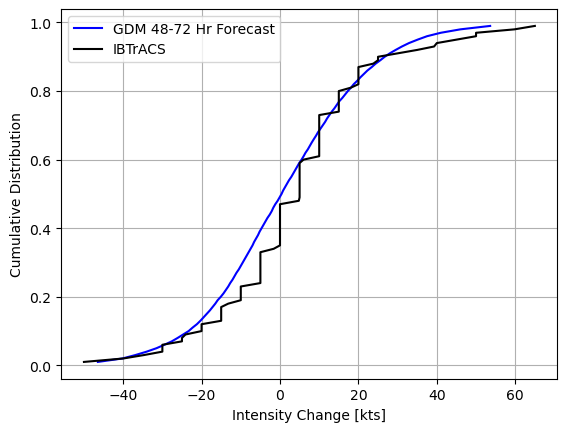

In [206]:
cumulative = np.linspace(0.01, 0.99, 99)
plt.plot(percentiles, cumulative, color='blue', label='GDM 48-72 Hr Forecast')
plt.plot(percentiles_bestrack, cumulative, color='black', label='IBTrACS')
plt.grid()
plt.xlabel('Intensity Change [kts]')
plt.ylabel('Cumulative Distribution')
plt.legend()
plt.savefig('intensity_change_48-72')

# Creating Rapid Intensification (RI) Reliability Diagrams 

In [27]:
## This will be the new and improved loop looping through all storms in the 2025 season! 

storm_num = 13 
hours = 0
records = []
## Loop through all 13 storms from the 2025 season!
for i in range(storm_num):
    storm = 'al' + f"{i+1:02d}" + '2025'
    bestrack = readbdeck(storm)
    ## Let's go through each time associated with the storm and pick out the associated track id.
    for j in range(len(np.unique(bestrack['initdatetime'].values))):
        ## Pick out the time in question
        date_in_question = np.unique(bestrack['initdatetime'].values)[j]
        ## Now let's open the file
        month = pd.to_datetime(date_in_question).month
        day = pd.to_datetime(date_in_question).day
        hour = pd.to_datetime(date_in_question).hour
        ## If it's a special hour/report, be sure to skip it! 
        if (hour % 6 != 0):
            continue
        if (month < 11):
            model_data = pd.read_csv('/tanglab_rit/ATM527/googleDeepMind/cyclogenesis_reliability_diagram_season/data/cyclogenesis/FNV3_' + str('2025') + '_' + f"{month:02d}" + '_' + 
                             f"{day:02d}" + 'T' + f"{hour:02d}" + '_00_cyclogenesis.csv', skiprows=6)
        else:
            model_data = pd.read_csv('/tanglab_rit/ATM527/googleDeepMind/DATA/Seasonal/FNV3_' + str("2025") + '_' + f"{month:02d}" + '_' + 
                             f"{day:02d}" + 'T' + f"{hour:02d}" + '_00_cyclogenesis.csv', skiprows=6)

        ## Let's check to see if date in question is within 24 hours of the last time from within the readbdeck dataset. If it is, we should continue forward with the loop.
        if (date_in_question + np.timedelta64(24, 'h') + np.timedelta64(hours, 'h') > bestrack['initdatetime'].values[-1]):
            continue

        ## Let's loop through all 50 ensemble members! 
        ensemble_members = 50
        hits = 0
        misses = 0
        num_events = 0
        df_atlantic = model_data[model_data['lat'] > 0]
        df_atlantic = df_atlantic[df_atlantic['lon'] < 0]
        df_atlantic = df_atlantic[df_atlantic['lon'] > -130]

        valid_time = np.empty(0)
        for k in range(len(df_atlantic)):
            valid_time = np.append(valid_time, datetime.strptime(df_atlantic['valid_time'].values[k], '%Y-%m-%d %H:%M:%S'))
        df_atlantic['Valid Time'] = valid_time
        for k in range(ensemble_members):
            df_ensemble = df_atlantic[df_atlantic['sample'] == k]
            ## Now let's pick out the storm in particular that we are interested in!
            df_storm = df_ensemble[df_ensemble['track_id'] == 'AL' + f"{i+1:02d}" + '2025']
            ## Let's take care of a few edge cases (i.e. 10/10 00z and 10/21 12z)
            if (day == 10 and month == 10 and hour == 0):
                df_storm = df_ensemble[df_ensemble['track_id'] == 'AL962025(2)']
            if (day == 21 and month == 10 and hour == 12):
                df_storm = df_ensemble[df_ensemble['track_id'] == 'AL982025(2)']
            ## If the length is zero, this likely means that the storm is still classified as an invest. That means that we need to find it in the track ids! 
            if (len(df_storm) == 0):
                track_ids = df_ensemble['track_id'].unique()
                ## Let's loop through all of the track_ids and find the unique one!
                for m in range(len(track_ids)):
                    ## If not an invest, then continue
                    if (type(track_ids[m]) == np.int64):
                        continue
                    if (track_ids[m][0:2] != 'AL'):
                        continue
                    # print(date_in_question)
                    ## If it is, let's see if it's within 1500km of the actual formation.
                    df_track = df_ensemble[df_ensemble['track_id'] == track_ids[m]]
                    storm_loc = (bestrack['flat'].values[j], bestrack['flon'].values[j])
                    model = (df_track['lat'].values[0], df_track['lon'].values[0])
                    distance = geodesic(storm_loc, model).km
                    if (distance <= 1500):
                        df_storm = df_track
            ## Let's get the forecast at x hours and compare to the forecast at x+24 hours. 
            ## Let's get the first and last times of the current storm. 
            if (len(df_storm) == 0):
                print(date_in_question)
                continue
            first_time = df_storm['Valid Time'].values[0]
            last_time = df_storm['Valid Time'].values[-1]
            ## If the storm lasts for less than 24 hours, then it can't possibly RI!!!
            time_in_question = first_time
            for m in range (1):
                ## Go through a loop 4 times to include the 0, 6, 12, 18, and 24th hour within the dataset.
                if (time_in_question + np.timedelta64(hours+24, 'h') > last_time):
                    continue
                ## Now let's consider the 24-hour intensity change.
                no_RI = True
                initial_time = df_storm[df_storm['Valid Time'] == time_in_question + np.timedelta64(hours, 'h')]
                ## If the initial time isn't in the dataset for some reason, never fear, just move on! 
                if (len(initial_time) != 0):
                    initial_intensity = initial_time['maximum_sustained_wind_speed_knots'].values[0]
                else:
                    continue
                final_time = df_storm[df_storm['Valid Time'] == time_in_question + np.timedelta64(hours+24, 'h')]
                ## If the final time isn't in the dataset for some reason, never fear, just move on! 
                if (len(final_time) != 0):
                    final_intensity = final_time['maximum_sustained_wind_speed_knots'].values[0]
                else:
                    continue
                if (final_intensity - initial_intensity >= 29.5):
                    no_RI = False
                if (no_RI):
                    misses += 1
                    num_events += 1
                else:
                    hits += 1
                    num_events += 1
        ## Calculate the hit frequency            
        if (num_events == 0):
            model_frequency = 0
        else:
            model_frequency = float(hits/(num_events))
    
        ## Now we need to calculate the observed frequency!
        ## The observed frequency is simply whether or not the storm with the code intensified!
        ## Let's see if the storm code is within the RI database.
        RI_storm = RI[RI['Code'] == 'AL' + f"{i+1:02d}" + "2025"]
        ## If the storm RI'd, then the observed frequency is one.
        dates = RI_storm['Time'].values
        dates = dates - np.timedelta64(hours, 'h')
        observed_frequency = 0
        time_in_question = date_in_question
        for m in range(1):
            if (time_in_question in dates):
                observed_frequency = 1
            time_in_question = time_in_question + np.timedelta64(6, 'h')
        if (hits == 0 and misses == 0):
            continue
        records.append([storm, date_in_question, hits, misses, model_frequency, observed_frequency])

In [74]:
for i in range(len(records)):
    new_records.append(records[i])

In [29]:
#summary df
records_df=pd.DataFrame(
    records,
    columns=["storm", "init_time", "hits", "misses", "p_forecast", "obs_event"]
)

In [39]:
ships = pd.read_csv('/tanglab_rit/ATM527/googleDeepMind/SHIPS_RI_Probabiltiies.csv')

In [40]:
entries = []
for i in range(len(ships)):
    entries.append([ships['Date:'][i], 0, 0, ships['SHIPS-RII'][i]/100, ships['Verification'][i]])
records_df = pd.DataFrame(
    entries,
    columns=["init_time", "hits", "misses", "ref_forecast", "obs_event"]
)

In [41]:
#computing refinement distribution function P(y_i), where y_i is the 
#probability of the ensemble member per initialization time, P(y_i) is the relative frequency 
# of the number of occurences of each ensemble probability to the total n forecasts
bins=np.array([-0.01, 0.01, 0.2, 0.4, 0.6, 0.8, 1.0])
records_df["bin"]=pd.cut(records_df["ref_forecast"], bins) #assigns each forecast prob value to each bin
N_i=records_df.groupby("bin").size()
n=len(records_df)
p_y=N_i/n

/tmp/ipykernel_1111253/2624812562.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  N_i=records_df.groupby("bin").size()


In [46]:
##computing calibration fcn P(O|Y)=P(O and Y)/P(y_i)
event_rows=records_df[records_df["obs_event"] >= 1]
joint=event_rows.groupby("bin").size()/len(records_df)
calibration=joint/p_y

/tmp/ipykernel_1111253/45687314.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  joint=event_rows.groupby("bin").size()/len(records_df)


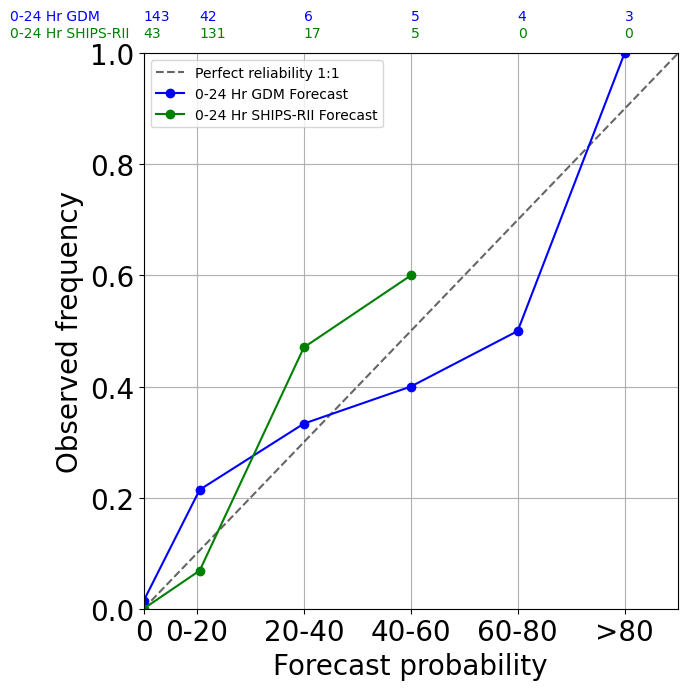

In [48]:
#calc bin centres for plotting
bin_centers=np.array([iv.left+0.5*(iv.right-iv.left) for iv in calibration.index])
#overall climatological event probability P(O=1)
clim_prob=records_df["obs_event"].mean()

fig,ax=plt.subplots(figsize=(7,7))

#perfect-reliability line (y = x)
x_line=np.linspace(0,1,201)
ax.plot(x_line,x_line,linestyle="--",color="black",label="Perfect reliability 1:1",alpha=0.6)

#calibration/attributes curves

ax.plot(bin_centers_1, calibration_1, color='blue', marker='o',
        linestyle='-', label='0-24 Hr GDM Forecast')

ax.plot(bin_centers, calibration.values, color='green', marker='o',
        linestyle='-', label='0-24 Hr SHIPS-RII Forecast')


## Add in numbers above the figure to display sample size information.
ax.text(bin_centers[0], 1.06, events[0][0], color='blue')
ax.text(bin_centers[0], 1.03, events[1][0], color='green')

ax.text(bin_centers[1], 1.06, events[0][0.1], color='blue')
ax.text(bin_centers[1], 1.03, events[1][0.1], color='green')

ax.text(bin_centers[2], 1.06, events[0][0.3], color='blue')
ax.text(bin_centers[2], 1.03, events[1][0.3], color='green')

ax.text(bin_centers[3], 1.06, events[0][0.5], color='blue')
ax.text(bin_centers[3], 1.03, events[1][0.5], color='green')

ax.text(bin_centers[4], 1.06, events[0][0.7], color='blue')
ax.text(bin_centers[4], 1.03, events[1][0.7], color='green')

ax.text(bin_centers[5], 1.06, events[0][0.9], color='blue')
ax.text(bin_centers[5], 1.03, events[1][0.9], color='green')

ax.text(bin_centers[0] - 0.25, 1.06, "0-24 Hr GDM", color='blue')
ax.text(bin_centers[0] - 0.25, 1.03, "0-24 Hr SHIPS-RII", color='green')


ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel(r"Forecast probability", fontsize=20)
plt.yticks(fontsize=20)

locations = [0, 0.1, 0.3, 0.5, 0.7, 0.9]
ax.set_xticks(locations)

labels = ["0", "0-20", '20-40', '40-60', '60-80', '>80']
ax.set_xticklabels(labels)
ax.set_ylabel(r"Observed frequency", fontsize=20)
plt.xticks(fontsize=20)
# ax.set_title("Attributes diagram for Rapid Intensification prediction",fontweight='bold')
ax.legend()

plt.grid()

#sharpness(refinement) histogram inset
plt.tight_layout()
plt.savefig('attribute_diagram_intensity_SHIPS_RII_2025Atl_season.png',dpi=600)
plt.show()